# Diverse families with mean-selected settings

The feasibility gate fails. The requested weak-marginal/strong-z contrast is not established by this grid; no p90 expansion is justified.

All six families—VAR, Wave, CML, Kuramoto, correlated Gaussian and correlated Cauchy—are retained. These are **24 local probes**, not the 289-SPI p90 catalogue. This experiment addresses the user’s diverse-system requirement; earlier factor-only examples are supporting evidence at most.

## Design

Nine settings per family and four scout realizations per setting are compared using only the standardized mean-probe vectors. A deterministic multi-start alternating search selects one setting per family to minimize their between-family mean differences. This is deliberate development design, not unsupervised discovery or a guaranteed global optimum. Settings were committed at `e1c39ae` before the fresh bank was generated. The selected generators then supply 32 fresh training and 32 fresh validation realizations per family, all at M16/T1000. Original held banks are untouched.

M16 provides 240 ordered channel pairs at moderate cost; these are not independent samples. Holding M and T fixed isolates this generator feasibility question before revisiting the requested nine-size grid. The independent-noise controls from the earlier six-family reports remain separate; this scout evaluates only the six correlated families. No families, parameters, seeds or embeddings are chosen using fresh validation outcomes.

In [1]:
from pathlib import Path
import pandas as pd,json
from IPython.display import display,Image
ROOT=Path.cwd().resolve()
while not (ROOT/'pyproject.toml').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
OUT=ROOT/'results/representation/diverse-marginal-scout-261005'
display(pd.read_csv(OUT/'selected-settings.csv'))

,family,phi,gain,courant,modes,alpha,eps,K,dt,max_delay,heterogeneity
0,VAR,0.2,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Wave,NaN,NaN,0.6,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2,CML,NaN,NaN,NaN,NaN,1.69,0.03,NaN,NaN,NaN,NaN
3,Kuramoto,NaN,NaN,NaN,NaN,NaN,NaN,8.0,0.1,NaN,NaN
4,Gaussian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
5,Cauchy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.5


## What “strength matched” means here

Channels are centered and scaled to unit sample variance. Each block has a shared target $\overline{|r|}\in[.065,.075]$ and $\bar r\in[.003,.007]$. Observation-noise amplitude, a noise rotation and channel polarities match these two summaries numerically. A weak native recording may need an added shared Gaussian observation input before attenuation. This is explicitly an observation model, not equal physical coupling or equal native Jacobian gain. Cauchy covariance is finite-sample only.

For the four dynamical families, the reported native variance fraction is the nominal $1/(1+b^2+\sigma^2)$, ignoring empirical cross terms, where $b$ is the common-input loading and $\sigma$ the added noise amplitude. It is a diagnostic of how much calibration changes the recording, not an exact variance decomposition. Neither added noise nor sign calibration is evidence of dependence-character isolation.

The probes cover contemporaneous, rank, lagged, precision/regularized covariance, spectral coherence and phase-locking summaries. Gaussian plug-in MI is explicitly not KSG MI; the focused catalogue is not an exact p90 subset. Means, seven distribution summaries per probe and correlations across aligned ordered off-diagonal entries are extracted from the same records.

In [2]:
display(pd.read_csv(OUT/'observation-summary.csv').round(4))
display(pd.read_csv(OUT/'metrics.csv').merge(pd.read_csv(OUT/'intervals.csv'),on='method').round(4))
display(pd.read_csv(OUT/'training-selected-means.csv').round(4))

,family,native_variance_fraction_median,common_boost_median,warnings
0,CML,0.6200,0.3293,0
1,Cauchy,NaN,0.0000,0
2,Gaussian,NaN,0.0000,0
3,Kuramoto,0.0701,0.0000,0
4,VAR,0.6358,0.3233,0
5,Wave,0.0910,0.0000,0


,method,BA,lower,upper
0,mean_linear,0.9792,0.9583,0.9948
1,mean_RBF,0.9688,0.9427,0.9896
2,mean_trees,0.9792,0.9583,0.9948
3,mean_selected_tree,0.6615,0.6146,0.7083
4,distribution_linear,0.9844,0.9635,1.0000
5,distribution_RBF,0.9688,0.9427,0.9896
6,distribution_trees,0.9792,0.9583,0.9948
7,distribution_selected_tree,0.5573,0.5000,0.6146
8,z_center,0.9219,0.8958,0.9479
9,z_standard,0.9062,0.8750,0.9375


,feature,training_F
0,Spearman_lag1_squared,837.7687
1,Pearson_lag1_squared,282.9787
2,GL_covariance_squared,155.3994
3,Pearson_squared,148.8765
4,Spearman_lag5_squared,140.8014


Mean and distribution controls include full linear, RBF and tree readouts, plus a training-ranked single-summary tree. The primary focused z readout is centered PCA20 plus logistic C1; standardized z is a sensitivity. Preprocessing and embeddings fit training only. Chance balanced accuracy is 1/6. Intervals resample the 32 validation blocks, preserving the six-family pairing; they do not account for the earlier choice to pursue this experimental direction. A prespecified development gate requires every mean readout ≤.30 and centered z ≥.70. Finite-readout weakness would not prove information absence.

The leftmost display is the actual one-dimensional signed mean correlation with explicitly meaningless vertical jitter, not a two-dimensional embedding. The remaining panels use fixed PCA/UMAP settings. UMAP uses the first 20 training-fitted PCs, 15 neighbors, min_dist .1 and seed261025; validation is transformed without refitting. Marker area scales as sqrt(M); all records here have M16. Visually mixed two-dimensional projections do not override successful classification.

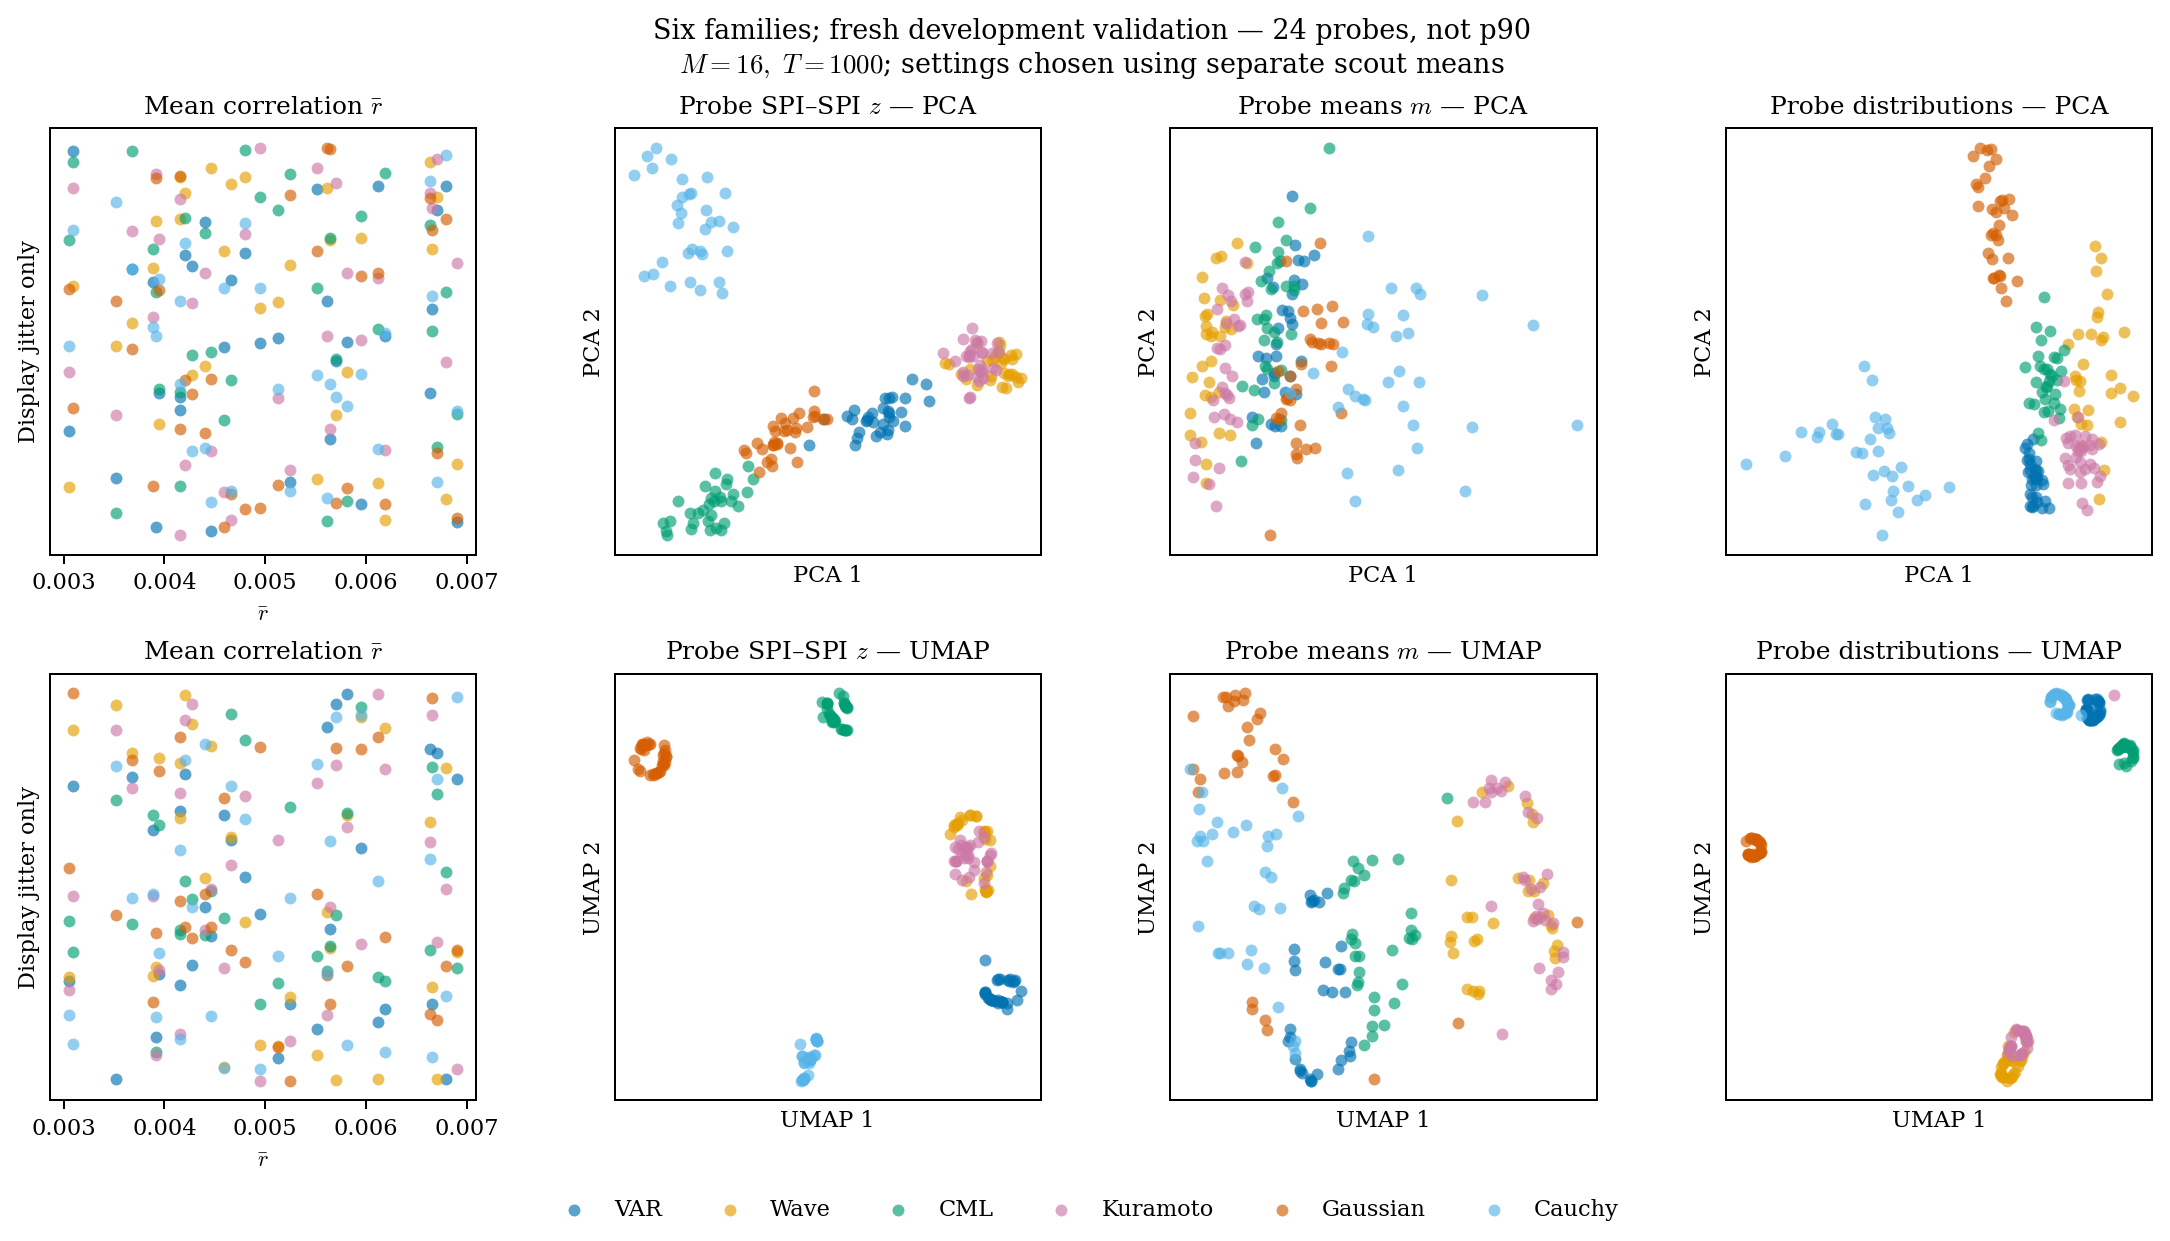

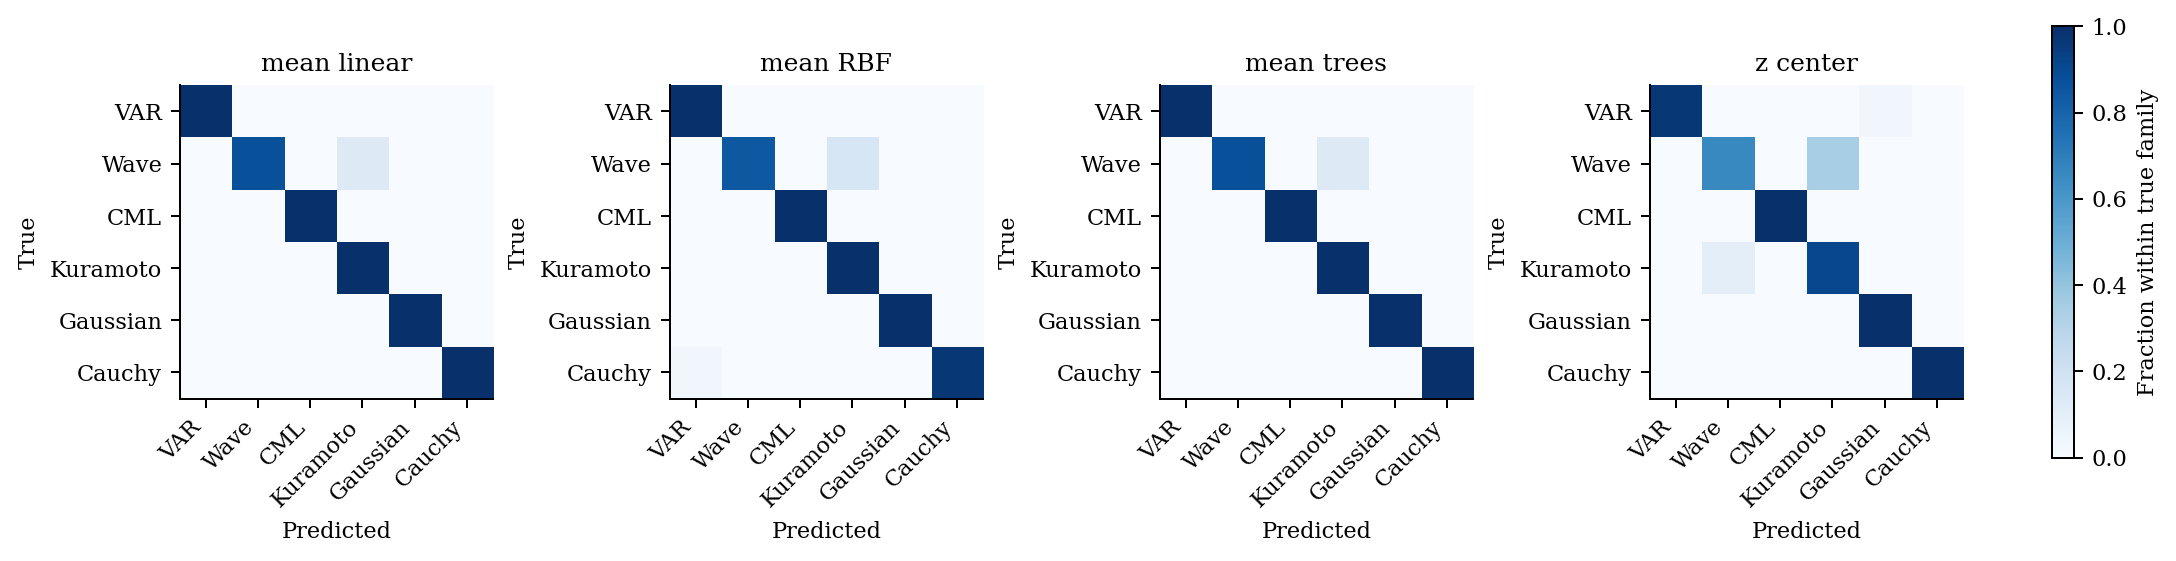

{'best_mean': 0.9791666666666666,
 'primary_z': 0.921875,
 'pass_gate': False,
 'gate': 'All mean readouts <=.30 and centered z >=.70; heuristic development gate, chance1/6. Failure stops this fixed grid without p90 submission.',
 'scope': 'Fresh development realizations; selected using separate scout means. No existing held banks opened; not p90.'}

In [3]:
display(Image(filename=str(OUT/'figures/six-family-embeddings.png')))
display(Image(filename=str(OUT/'figures/confusion.png')))
display(json.loads((OUT/'decision.json').read_text()))

## What the visual contrast does establish

The fixed z PCA2 view is clearer than the means PCA2 view. An exploratory diagnostic added after inspecting the fixed figures fits the same logistic C1 readout to their first two PCs: z gives 89.1%, means 67.7%, distributions 93.8%. Validation silhouette is .447 for z versus .044 for means. This is a low-dimensional geometry benefit in this focused catalogue, not evidence that the marginal representations lack class information; their full-vector accuracy is higher. No embedding or parameter was changed for this diagnostic.

The strongest single mean ranked on training is squared lag-1 Spearman correlation. Matching contemporaneous correlation leaves lagged rank dependence informative. Calibration also dilutes the nominal native variance fraction to about 7% for Kuramoto and 9% for Wave (versus roughly 62–64% for CML/VAR). This limits the physical interpretation of the calibrated systems, independently of their classification scores.

In [4]:
display(pd.read_csv(OUT/'pca2-diagnostic.csv').round(4))

,representation,BA,silhouette
0,mean,0.6771,0.0436
1,distribution,0.9375,0.4959
2,z,0.8906,0.4468


## Scope

This tests a finite, declared parameter grid and observation model. Failure does not prove that a diverse-system counterexample is impossible. It does show that matching two scalar strengths and choosing native settings by marginal similarity are insufficient for this construction. Raw means across many dependence measures can retain information about dependence character: a distinction between “strength” and “character” is not a general theorem separating m from z. Cliff et al. assemble measures with diverse mathematical sensitivities; this experiment tests an additional representation, not a criticism of that work. [Cliff et al., Unifying pairwise interactions in complex dynamics](https://www.nature.com/articles/s43588-023-00519-x).

For missing ignored feature caches, run `python -m scripts.audit_diverse_marginal_scout --rebuild-missing-caches`, then `python -m scripts.scout_diverse_marginal_match evaluate` and `python -m scripts.report_diverse_marginal_scout`. The original scout/fresh stages are immutable; cache restoration does not repeat parameter selection. Protocol, selected settings, all failures, source hashes and numerical results live alongside this report’s figures.

In [5]:
display(json.loads((OUT/'protocol.json').read_text()))
display(json.loads((OUT/'audit.json').read_text()))

{'seed': 261025,
 'M': 16,
 'T': 1000,
 'configurations': {'VAR': [{'phi': 0.2, 'gain': 0.05},
   {'phi': 0.2, 'gain': 0.1},
   {'phi': 0.2, 'gain': 0.15},
   {'phi': 0.5, 'gain': 0.05},
   {'phi': 0.5, 'gain': 0.1},
   {'phi': 0.5, 'gain': 0.15},
   {'phi': 0.8, 'gain': 0.05},
   {'phi': 0.8, 'gain': 0.1},
   {'phi': 0.8, 'gain': 0.15}],
  'Wave': [{'courant': 0.05, 'modes': 2},
   {'courant': 0.05, 'modes': 4},
   {'courant': 0.05, 'modes': 8},
   {'courant': 0.2, 'modes': 2},
   {'courant': 0.2, 'modes': 4},
   {'courant': 0.2, 'modes': 8},
   {'courant': 0.6, 'modes': 2},
   {'courant': 0.6, 'modes': 4},
   {'courant': 0.6, 'modes': 8}],
  'CML': [{'alpha': 1.69, 'eps': 0.03},
   {'alpha': 1.69, 'eps': 0.15},
   {'alpha': 1.69, 'eps': 0.3},
   {'alpha': 1.895, 'eps': 0.03},
   {'alpha': 1.895, 'eps': 0.15},
   {'alpha': 1.895, 'eps': 0.3},
   {'alpha': 2.0, 'eps': 0.03},
   {'alpha': 2.0, 'eps': 0.15},
   {'alpha': 2.0, 'eps': 0.3}],
  'Kuramoto': [{'K': 0.5, 'dt': 0.01},
   {'K': 

{'source_bindings_verified': True,
 'source_freeze_commit': 'e1c39ae',
 'fresh_features_sha256': '6d9954056497e095474b37c35f7e9ad86cafde610d15f9ea1385252fd56fd7ba',
 'fresh_rows_sha256': 'c0fe8af25439fbe42891dce5bf083a9404e4a5b4d8387364a1f12ba89fad5fcb',
 'scout_rows': 216,
 'fresh_rows': 384,
 'failures': 0,
 'probe_count': 24,
 'max_signed_error': 4.0609876572617054e-15,
 'max_absolute_error': 2.08305594995295e-14,
 'nonfinite_z': 0,
 'replays': [{'family': 'VAR', 'bit_exact_features': True},
  {'family': 'Wave', 'bit_exact_features': True},
  {'family': 'CML', 'bit_exact_features': True},
  {'family': 'Kuramoto', 'bit_exact_features': True},
  {'family': 'Gaussian', 'bit_exact_features': True},
  {'family': 'Cauchy', 'bit_exact_features': True}],
 'package_versions': {'numpy': '2.3.5',
  'scipy': '1.15.3',
  'scikit-learn': '1.7.2',
  'umap-learn': '0.5.11'},
 'scope': 'Six selected fresh block0 records replay bit-exact. Independent covariance and first-z formula checks. No complete